<a href="https://colab.research.google.com/github/MariaBatoorina/electric-vehicles-analysis/blob/main/Geospatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd

df = pd.read_csv('Electric_Vehicle_Data_CLEANED.csv', low_memory=False)
total_rows = len(df)
coord_rows = df[['Latitude', 'Longitude']].dropna().shape[0]

#print(df[['Latitude', 'Longitude']].head(3))
print(f"Загалом записів: {total_rows:,}")
print(f"Координат є: {coord_rows:,}")

Загалом записів: 250,658
Координат є: 250,643


In [32]:
!pip install -U kaleido
import plotly.express as px
import plotly.io as pio
import os

# Створюємо папку
os.makedirs('visualizations', exist_ok=True)

# ============================================
# 1. КАРТА З ТОЧКАМИ (Plotly)
# ============================================

sample_size = 2000
map_data = df.dropna(subset=['Latitude', 'Longitude']).sample(min(sample_size, len(df)))

fig = px.scatter_mapbox(
    map_data,
    lat='Latitude',
    lon='Longitude',
    hover_name='City',
    hover_data={
        'Make': True,
        'Model': True,
        'Model Year': True,
        'Latitude': False,
        'Longitude': False
    },
    color='Make',
    zoom=8,
    title=f'Розташування електромобілів (вибірка {len(map_data)})',
    height=600,
    width=1000
)
fig.update_layout(mapbox_style='open-street-map')
fig.show()

# Збереження як PNG (через plotly.io)
try:
    pio.write_image(fig, 'visualizations/ev_map.png')
    print("✅ Карта збережена як ev_map.png")
except:
    print("⚠️ Не вдалося зберегти PNG. Спробуйте встановити kaleido: pip install -U kaleido")
    # Альтернатива: зберегти як HTML
    fig.write_html('visualizations/ev_map.html')
    print("✅ Карта збережена як ev_map.html (відкрийте в браузері)")

# ============================================
# 2. ТЕПЛОВА КАРТА (Folium)
# ============================================

import folium
from folium.plugins import HeatMap

center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=8)
heat_data = [[row['Latitude'], row['Longitude']] for _, row in df.dropna(subset=['Latitude', 'Longitude']).sample(min(1000, len(df))).iterrows()]
HeatMap(heat_data).add_to(m)

# Збереження як HTML
m.save('visualizations/ev_heatmap.html')
print("✅ Теплова карта збережена як ev_heatmap.html")

# Відображення
display(m)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 734.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.3 MB/s eta 0:00:00


⚠️ Не вдалося зберегти PNG. Спробуйте встановити kaleido: pip install -U kaleido
✅ Карта збережена як ev_map.html (відкрийте в браузері)
✅ Теплова карта збережена як ev_heatmap.html


### Ключові висновки:

1. Найбільша концентрація електромобілів - у King County (Сіетл, Белв'ю, Редмонд). Це пов'язано з високим рівнем доходів, технологічними компаніями та розвиненою інфраструктурою зарядних станцій.

2. Друга зона концентрації - північні передмістя (Snohomish County), що свідчить про поширення EV за межі центру.

3. Мала кількість EV у сільських районах - свідчить про необхідність розвитку зарядної інфраструктури за межами великих міст.

# Статистика по штатах

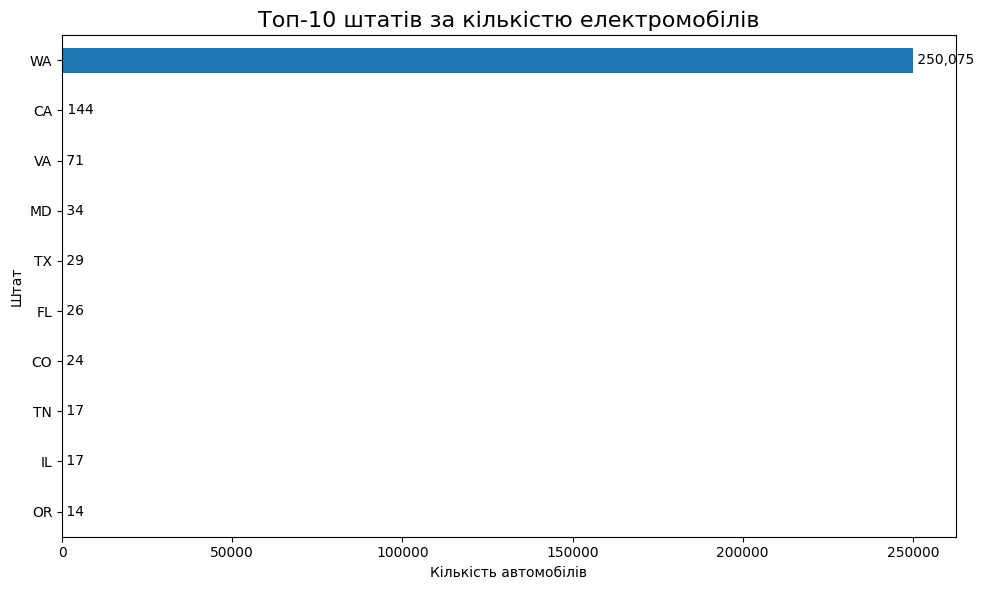

In [10]:
state_counts = df['State'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
bars = state_counts.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title('Топ-10 штатів за кількістю електромобілів', fontsize=16)
ax.set_xlabel('Кількість автомобілів')
ax.set_ylabel('Штат')

for i, value in enumerate(state_counts.sort_values()):
    ax.text(value, i, f' {value:,}', va='center')

plt.tight_layout()
plt.show()

###Ключові висновки:

1. Дані зосереджені у штаті Вашингтон (WA) - 99.77% всіх записів.

2. Поодинокі записи з інших штатів - Каліфорнія (144), Вірджинія (71), Меріленд (34), Техас (29) - становлять менше 1% даних.


#Статистика по містах і округах

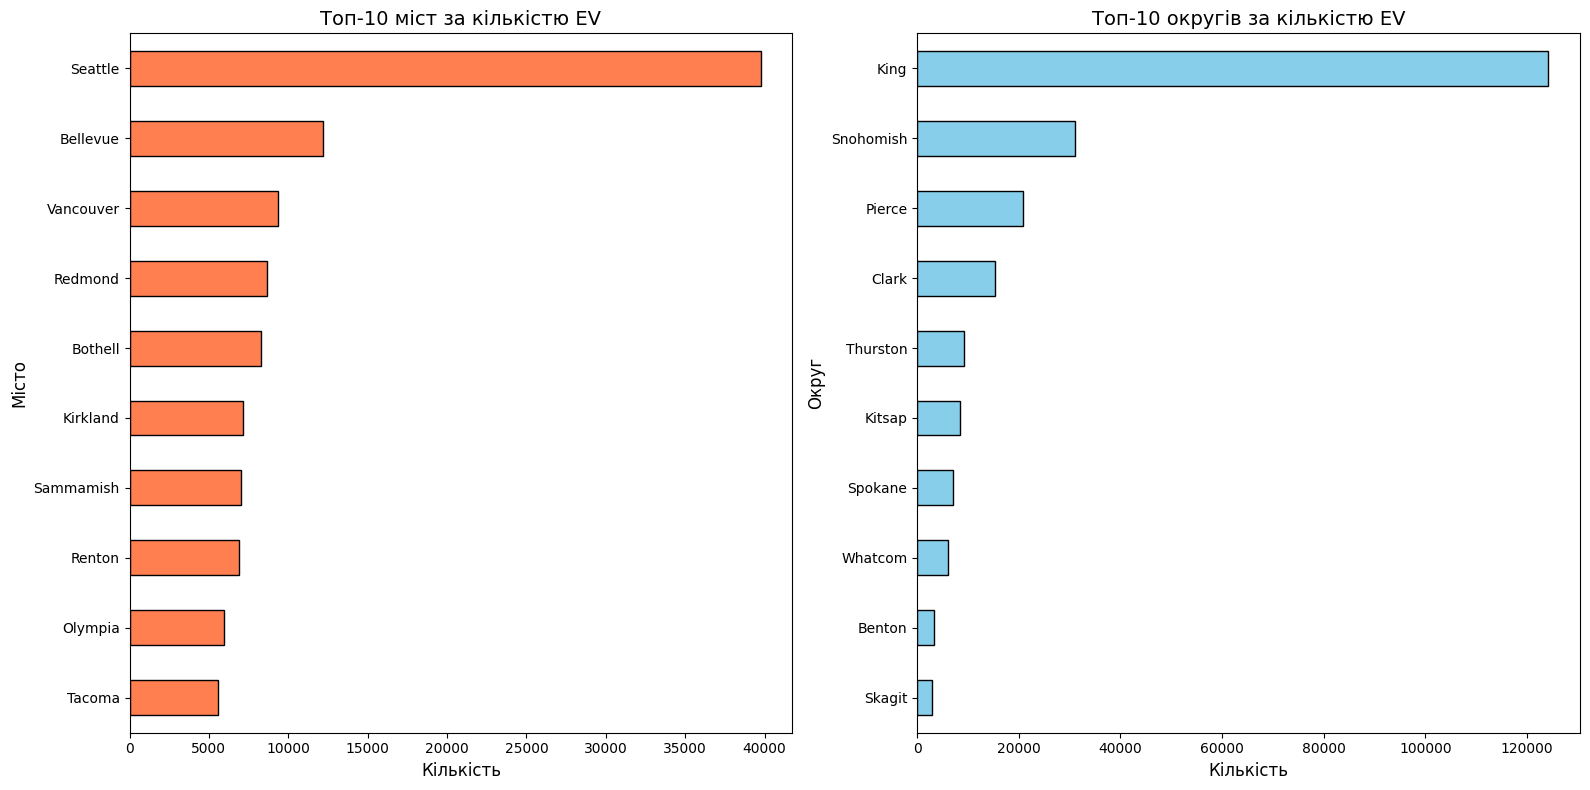

In [27]:
county_counts = df['County'].value_counts()
city_counts = df['City'].value_counts()

#print("\nТоп 10 міст за кількістю EV:")
#print(city_counts.head(10))
#print("\nТоп 10 округів за кількістю EV:")
#print(county_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

city_counts.head(10).sort_values().plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Топ-10 міст за кількістю EV', fontsize=14)
axes[0].set_xlabel('Кількість', fontsize=12)
axes[0].set_ylabel('Місто', fontsize=12)

county_counts.head(10).sort_values().plot(kind='barh', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Топ-10 округів за кількістю EV', fontsize=14)
axes[1].set_xlabel('Кількість', fontsize=12)
axes[1].set_ylabel('Округ', fontsize=12)

plt.tight_layout()
plt.savefig('visualizations/top_cities_counties.png', dpi=300)
plt.show()

###Статистика:
| Показник | Значення |
|----------|----------|
| **Найпопулярніший округ** | King (124,210 авто, 49.7%) |
| **Найпопулярніше місто** | Seattle (39,767 авто, 15.9%) |
| **Топ-3 округи** | 70.4% ринку |
| **Топ-5 міст** | 31.3% ринку |

###Ключові висновки:

1. King County домінує - 124,210 авто (49.7% всіх EV). Це пояснюється тим, що округ включає Сіетл - технологічний та економічний центр штату Вашингтон.

2. Seattle - найпопулярніше місто - 39,767 авто (15.9%). Кожне 6-те авто в датасеті зареєстроване в Сіетлі.

3. Топ-3 округи (King, Snohomish, Pierce) займають 70.4% ринку. Це означає, що більшість електромобілів зосереджена всього в 3 округах.

4. Топ-5 міст (Seattle, Bellevue, Vancouver, Redmond, Bothell) займають 31.3% ринку.

5. Нерівномірний розподіл — 224 округи і 813 міст, але більшість авто зосереджена у великих містах. Це свідчить про те, що ринок електромобілів все ще сконцентрований в урбанізованих районах.

